# 1. Temporal-difference-learning-SARSA-algorithm

In this notebook, we are going to learn about how to implement SARSA algorithm to solve frozen lake environment problem in reinforcement learning. 

## Setup froken lake env

In [1]:
from frozen_lake_environment import generate_grid_randomly, FrozenLakeEnvironment, State
import numpy as np 
from matplotlib import pyplot
from visual_utils import render_policy_and_value, animate_policy_value_video

In [2]:
# lake_grid =generate_grid_randomly(3, 3, 1)
lake_grid = [['F', 'F', 'F'],
             ['F', 'H', 'F'],
             ['F', 'F', 'G']]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}


In [3]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [4]:
## TD learning - SARSA algorithm

### Comparison between TD learning and Monte-Carlo based learning
- **Update timing:**
  - Monte Carlo: Updates the value only after the episode ends, when the full return is known.
  - Temporal Difference: Updates the value at every step, without waiting for the episode to finish.

- **Return estimation:**
  - Monte Carlo: Uses the actual return $G_t$ computed from the complete future rewards of the episode.
  - Temporal Difference: Uses an estimated return, bootstrapping from the current value estimate.

- **Bootstrapping:**
  - Monte Carlo: Does not use bootstrapping; updates are based only on real observed returns.
  - Temporal Difference: Uses bootstrapping, updating values using other estimated values.

- **Episode requirement:**
  - Monte Carlo: Requires complete episodes; works only in episodic tasks.
  - Temporal Difference: Can learn before an episode ends and works in both episodic and continuing tasks.

- **Learning speed:**
  - Monte Carlo: Learning is slower because updates occur only after episodes finish.
  - Temporal Difference: Learning is faster because updates occur at every step.

- **Variance and bias:**
  - Monte Carlo: High variance, low bias since it uses full returns.
  - Temporal Difference: Lower variance, higher bias due to bootstrapping

### why is it called "SARSA"?
 - each step of the algorithm involves ($s_t$, $a_t$, $r_{t+1}$, $s_{t+1}$, $a_{t+1}$)
 - SARSA stands for state-action-reward-state-action

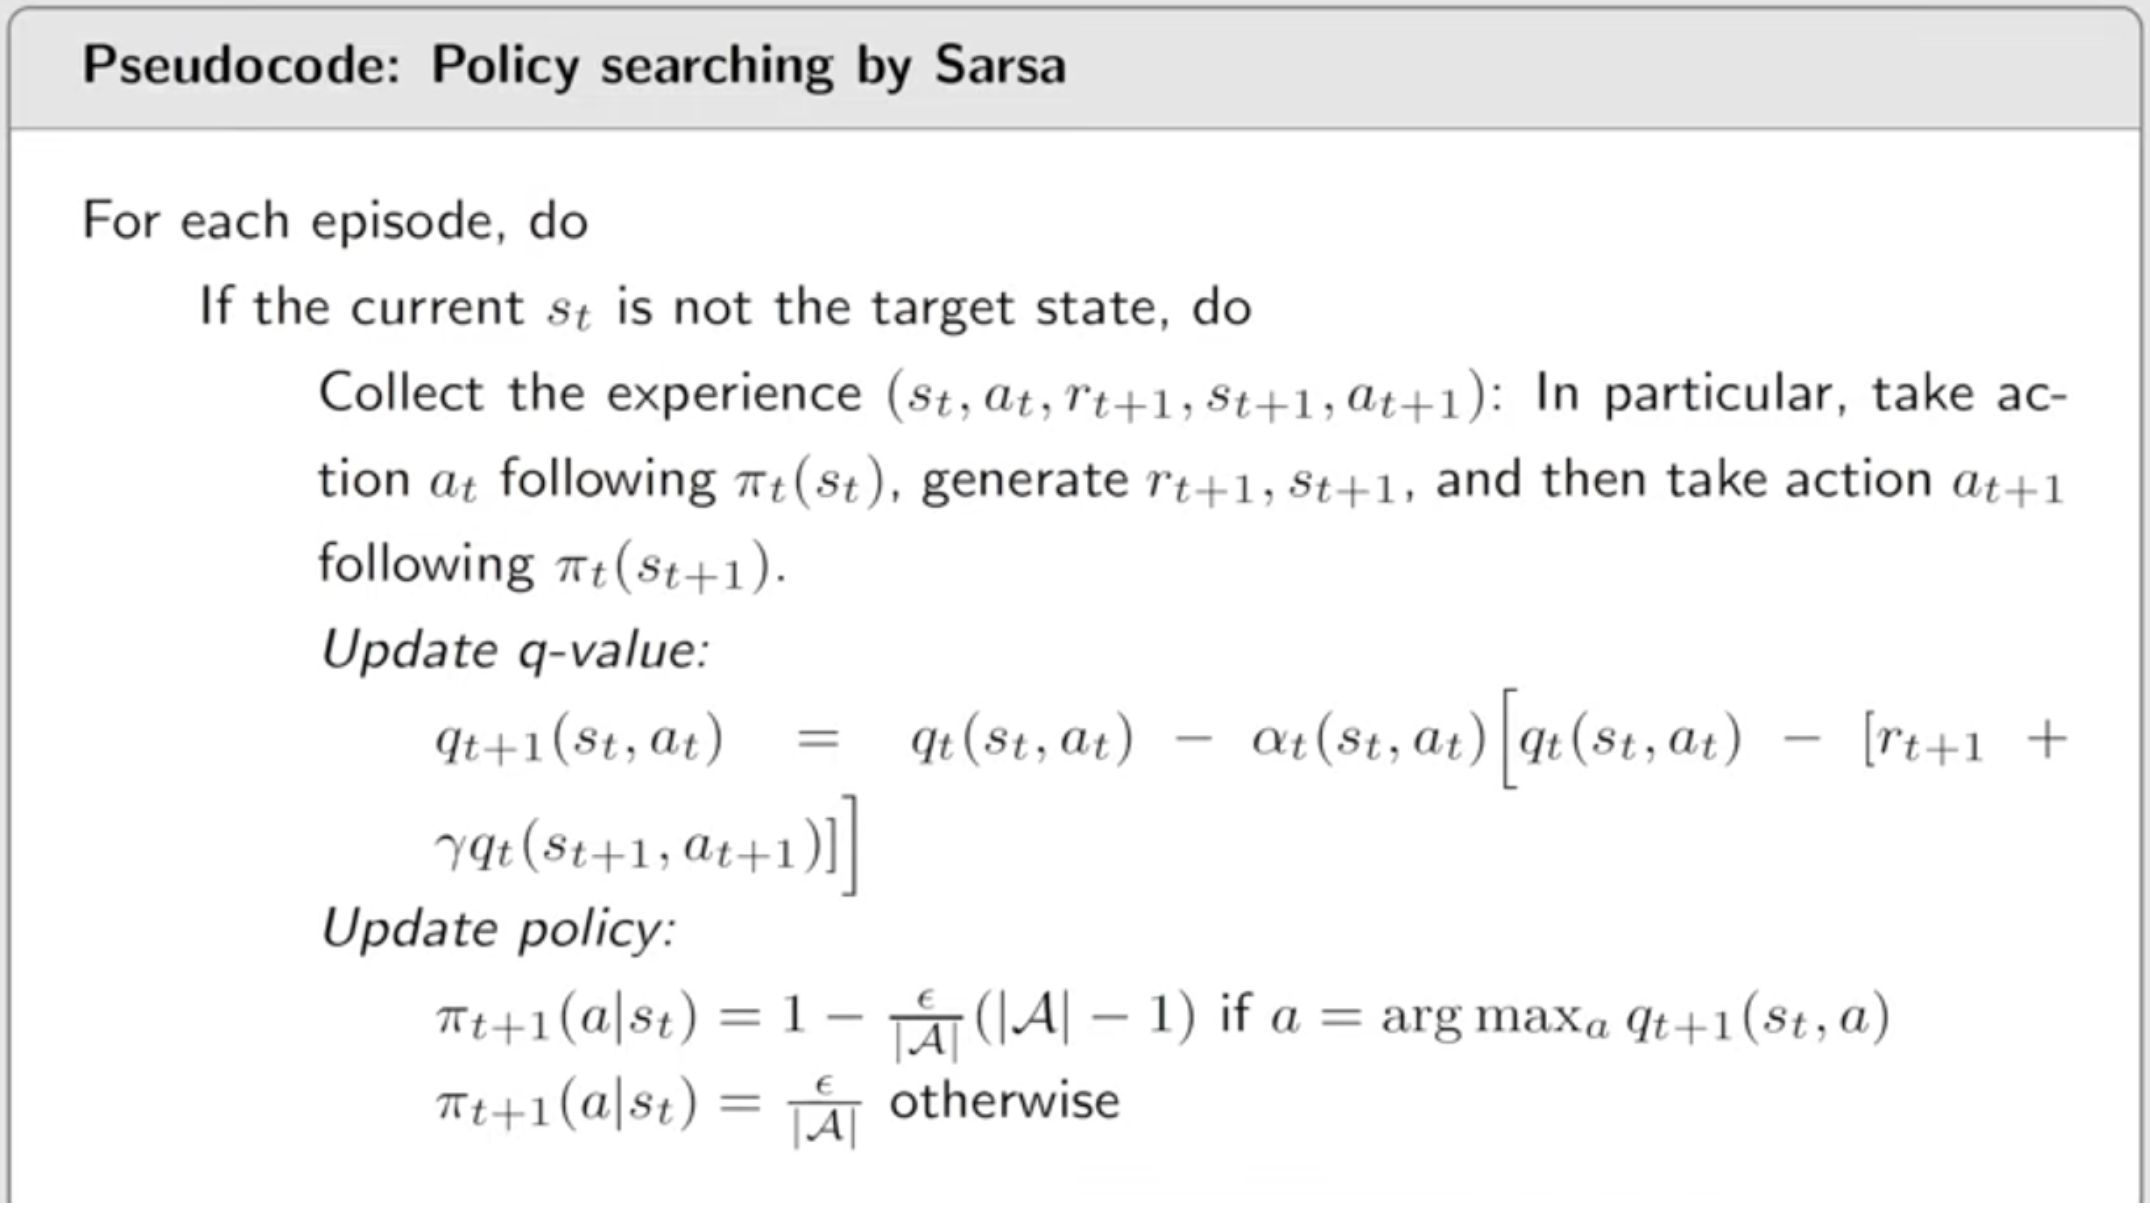

In [5]:
import random

In [6]:
# def randomly_state_action_pair(state_list, action_list):
#     # select element uniformly will ensure all the state, action will be selected eventually
#     s = random.choice(state_list)
#     a = random.choice(action_list)
#     return (s, a)

In [7]:
def get_epsilon_greedy_policy(Q, state, actions, epsilon=0.2):
    if random.random() < epsilon:
        return random.choice(actions) # explore
    else:
        return np.argmax(Q[state.idx]) # exploit


def get_greedy_policy(env, Q, states):
    policy = np.zeros(env.n_states, dtype=np.int8)
    for s in states:
        policy[s.idx] = np.argmax(Q[s.idx])
    return policy.tolist()

In [8]:
def run_episode(env, Q, state, action, episode_idx, alpha=0.1, gamma=0.1, verbose=0):
    step = 0
    while True:
        result = env.step(state, action)
        reward = result["reward"]

        next_state = result["new_state"]
        is_terminated = result["is_terminated"]

        next_action = get_epsilon_greedy_policy(Q, next_state, env.all_action_idx)

        # ------ update Q value ------
        Q[state.idx][action] = Q[state.idx][action] - alpha*(Q[state.idx][action] - (reward + gamma*Q[next_state.idx][next_action])) 
        # ---------------------------

        prev_state = state
        
        state = next_state
        action = next_action
        
        if verbose == 1:
            print(f"step {step}: state: {prev_state.coord} -> Action: {action} -> Reward: {reward} -> Next state: {next_state.coord}")
        elif verbose == 2:
            states_list = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
            policy = get_greedy_policy(env, Q, states_list)
            
            env.render(policy, state, episode_idx, step, reward)
            
        if is_terminated:
            break
        step += 1

    states_list = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]        
    greedy_policy = get_greedy_policy(env, Q, states_list)
    
    return Q, greedy_policy

In [9]:
def run_sarsa(env, n_episodes=500, alpha=0.2, gamma=0.99, verbose=0):
    policy_history = []
    Q_history = []

    # states_list = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    # actions_list = list(env.action_to_idx.values())
    
    policy = np.zeros(env.n_states, dtype=np.int32)    
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float32)
    
    for episode_idx in range(n_episodes):
        # s, a = randomly_state_action_pair(states_list,
        #                                   actions_list)

        initial_state = env.find('S')
        initial_action = 2 #randomly picked

        Q, greedy_policy = run_episode(env,
                                       Q, 
                                       initial_state, 
                                       initial_action, 
                                       episode_idx,
                                       alpha=alpha,
                                       gamma=gamma,
                                       verbose=verbose)
        
        policy_history.append(greedy_policy)
        Q_history.append(Q)
    return Q, policy_history, Q_history

In [10]:
lake_grid = [["F", "F", "S", "F"],
             ["F", "F", "H", "F"],
             ["F", "F", "F", "G"],
             ["F", "H", "F", "F"]]
# lake_grid = [["F", "F", "S", "F", "H"],
#              ["F", "F", "H", "F", "F"],
#              ["F", "F", "F", "G", "F"],
#              ["F", "H", "F", "F", "F"],
#              ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [11]:
frozen_lake.n_rows

4

In [12]:
Q, policy_history, Q_history = run_sarsa(frozen_lake, n_episodes=15000, verbose=0)

In [13]:
policy = policy_history[-1]
np.array(policy)

array([2, 2, 2, 3, 3, 3, 0, 3, 3, 0, 2, 0, 3, 0, 3, 0])

In [14]:
def convert_1d_to_2d_policy(policy_1d, n_rows, n_cols):
    policy_2d = np.zeros((n_rows, n_cols),dtype=np.int16)

    for idx, value in enumerate(policy_1d):
        r, c = State(idx, n_cols).coord
        policy_2d[r][c] = value
    return policy_2d

In [15]:
policy_2d = convert_1d_to_2d_policy(policy, frozen_lake.n_rows, frozen_lake.n_cols)
policy_2d

array([[2, 2, 2, 3],
       [3, 3, 0, 3],
       [3, 0, 2, 0],
       [3, 0, 3, 0]], dtype=int16)

In [16]:
# Render policy

In [17]:
import pandas as pd
from IPython.display import display

In [18]:
policy, Q

([2, 2, 2, 3, 3, 3, 0, 3, 3, 0, 2, 0, 3, 0, 3, 0],
 array([[3.690912  , 3.6210587 , 4.561869  , 3.6699123 ],
        [3.8443673 , 3.2325263 , 5.5405207 , 4.3010144 ],
        [4.342923  , 0.7405546 , 5.1970577 , 4.4714336 ],
        [6.561163  , 6.244029  , 6.2733283 , 6.5689425 ],
        [3.054957  , 3.198185  , 3.3301604 , 3.5511813 ],
        [2.5295866 , 2.068358  , 0.38062578, 2.840568  ],
        [0.        , 0.        , 0.        , 0.        ],
        [3.4579964 , 5.2964296 , 4.927286  , 6.079765  ],
        [2.7258372 , 2.066989  , 2.695908  , 3.6259305 ],
        [3.464227  , 0.05259042, 1.43571   , 2.4198384 ],
        [3.4339817 , 1.6       , 6.7819853 , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.28100088, 0.7370743 , 0.        , 1.8136345 ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.39549193],
        [0.        , 0.        , 0.        , 0.        ]], dtype=float32))

In [19]:
render_policy_and_value(frozen_lake, policy, Q)

Policy:


,0,1,2,3
0,→,→,🚀 →,↑
1,↑,↑,🕳️,↑
2,↑,←,→,🏁
3,↑,🕳️,↑,←


state-action value Function:


,0,1,2,3
0,3.69,3.62,4.56,3.67
1,3.84,3.23,5.54,4.30
2,4.34,0.74,5.20,4.47
3,6.56,6.24,6.27,6.57
4,3.05,3.20,3.33,3.55
5,2.53,2.07,0.38,2.84
6,0.00,0.00,0.00,0.00
7,3.46,5.30,4.93,6.08
8,2.73,2.07,2.70,3.63
9,3.46,0.05,1.44,2.42


In [20]:
# Play with different grid setup

In [21]:
grid = generate_grid_randomly(4, 4, n_holes=4)
grid

[['S', 'H', 'F', 'H'],
 ['F', 'F', 'F', 'F'],
 ['H', 'G', 'F', 'F'],
 ['H', 'F', 'F', 'F']]

In [22]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [23]:
Q, policy_history, Q_history = run_sarsa(frozen_lake, n_episodes=5000, verbose=0)

In [24]:
policy = policy_history[-1]

In [25]:
render_policy_and_value(frozen_lake, policy, None)

Policy:


,0,1,2,3
0,🚀 ↓,🕳️,↓,🕳️
1,→,↓,←,↓
2,🕳️,🏁,←,←
3,🕳️,←,←,←
